In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
.master('local[*]')\
.getOrCreate()
sc = spark.sparkContext

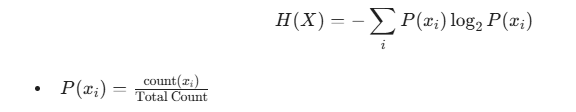

In [2]:
import numpy as np
data = ["A", "B", "A", "C", "A", "B"]
rdd = sc.parallelize(data)

In [3]:
#전체 개수 N
total_count = rdd.count()
b_n = sc.broadcast(total_count)
#빈도수 계산
counts = rdd.map(lambda x:(x,1)).reduceByKey(lambda a, b : a+b)

In [4]:
#엔트로피 계산
def calc(item):
  count = item[1]
  n = b_n.value
  #확률 p(x)
  prob = count / n
  #-p log p
  return -prob * np.log2(prob)

In [5]:
entropy = counts.map(calc).sum()
print(f"Entropy: {entropy}")

Entropy: 1.4591479170272448
